# 1 Giới thiệu

Notebook này trình bày quá trình Phân tích Khám phá Dữ liệu (Exploratory Data Analysis – EDA) trên bộ dữ liệu thời tiết của Thành phố Hồ Chí Minh.
Dữ liệu đã được tiền xử lý và làm sạch ở bước trước, do đó trong notebook này, phân tích tập trung hoàn toàn vào việc khám phá, trực quan hóa và rút ra các đặc điểm chính của dữ liệu.

Mục tiêu của EDA bao gồm:

- Hiểu cấu trúc và đặc điểm tổng quan của dữ liệu

- Phân tích phân phối của các biến khí tượng chính

- Khám phá mối quan hệ giữa các biến

- Phân tích xu hướng và tính mùa vụ theo thời gian

- Rút ra các nhận xét và kết luận quan trọng

# 2 Tổng quan về dữ liệu

## 2.1 Cấu trúc dữ liệu

Bộ dữ liệu bao gồm khoảng 35.000 quan sát, được thu thập trong giai đoạn từ năm 2009 đến năm 2020.
Dữ liệu gồm:

Các biến số: nhiệt độ, nhiệt độ cảm nhận, độ ẩm, lượng mưa, áp suất, tốc độ gió, gió giật, độ mây.

Các biến phân loại: trạng thái thời tiết, tầm nhìn, hướng gió.

Dữ liệu được gắn chỉ mục thời gian (Datetime), cho phép thực hiện các phân tích chuỗi thời gian.

## 2.2 Kiểm tra dữ liệu ban đầu

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()
weather = list(uploaded.keys())[0]
weather = pd.read_csv(weather)
weather

Saving HCM_Weather_Final_Clean.csv to HCM_Weather_Final_Clean.csv


,Datetime,Weather,Temp,Feels,Gust,Rain,Humidity,Cloud,Pressure,Vis,Wind Speed,Wind Direction
0,2009-01-01 00:00:00,Mist,23.0,25.0,15.0,0.0,0.97,1.00,1010.0,Poor,9.0,NNW
1,2009-01-01 03:00:00,Rain,22.0,25.0,13.0,0.4,0.97,0.84,1010.0,Poor,9.0,NNW
2,2009-01-01 06:00:00,Mist,22.0,25.0,8.0,0.0,0.98,1.00,1011.0,Poor,6.0,N
3,2009-01-01 09:00:00,Cloudy,27.0,31.0,7.0,0.1,0.83,0.64,1011.0,Excellent,6.0,NNE
4,2009-01-01 12:00:00,Cloudy,28.0,34.0,3.0,0.0,0.76,0.62,1010.0,Excellent,3.0,NE
...,...,...,...,...,...,...,...,...,...,...,...,...
34971,2020-12-20 09:00:00,Cloudy,26.0,28.0,22.0,0.0,0.64,0.14,1012.0,Excellent,17.0,NNE
34972,2020-12-20 12:00:00,Cloudy,30.0,31.0,19.0,0.0,0.54,0.13,1010.0,Excellent,17.0,NNE
34973,2020-12-20 15:00:00,Cloudy,31.0,33.0,18.0,0.0,0.55,0.12,1008.0,Excellent,14.0,WSW
34974,2020-12-20 18:00:00,Cloudy,28.0,30.0,24.0,0.0,0.60,0.18,1009.0,Excellent,15.0,SE


In [ ]:
weather = pd.read_csv(
    "HCM_Weather_Final_Clean.csv",
    index_col=0,
    parse_dates=True
)
weather.head()

,Weather,Temp,Feels,Gust,Rain,Humidity,Cloud,Pressure,Vis,Wind Speed,Wind Direction
Datetime,,,,,,,,,,,
2009-01-01 00:00:00,Mist,23.0,25.0,15.0,0.0,0.97,1.00,1010.0,Poor,9.0,NNW
2009-01-01 03:00:00,Rain,22.0,25.0,13.0,0.4,0.97,0.84,1010.0,Poor,9.0,NNW
2009-01-01 06:00:00,Mist,22.0,25.0,8.0,0.0,0.98,1.00,1011.0,Poor,6.0,N
2009-01-01 09:00:00,Cloudy,27.0,31.0,7.0,0.1,0.83,0.64,1011.0,Excellent,6.0,NNE
2009-01-01 12:00:00,Cloudy,28.0,34.0,3.0,0.0,0.76,0.62,1010.0,Excellent,3.0,NE


In [ ]:
weather.tail()

,Weather,Temp,Feels,Gust,Rain,Humidity,Cloud,Pressure,Vis,Wind Speed,Wind Direction
Datetime,,,,,,,,,,,
2020-12-20 09:00:00,Cloudy,26.0,28.0,22.0,0.0,0.64,0.14,1012.0,Excellent,17.0,NNE
2020-12-20 12:00:00,Cloudy,30.0,31.0,19.0,0.0,0.54,0.13,1010.0,Excellent,17.0,NNE
2020-12-20 15:00:00,Cloudy,31.0,33.0,18.0,0.0,0.55,0.12,1008.0,Excellent,14.0,WSW
2020-12-20 18:00:00,Cloudy,28.0,30.0,24.0,0.0,0.60,0.18,1009.0,Excellent,15.0,SE
2020-12-20 21:00:00,Cloudy,25.0,27.0,22.0,0.0,0.64,0.15,1011.0,Excellent,14.0,NNE


In [ ]:
weather.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 34976 entries, 2009-01-01 00:00:00 to 2020-12-20 21:00:00
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Weather         34976 non-null  object 
 1   Temp            34976 non-null  float64
 2   Feels           34976 non-null  float64
 3   Gust            34976 non-null  float64
 4   Rain            34976 non-null  float64
 5   Humidity        34976 non-null  float64
 6   Cloud           34976 non-null  float64
 7   Pressure        34976 non-null  float64
 8   Vis             34976 non-null  object 
 9   Wind Speed      34976 non-null  float64
 10  Wind Direction  34976 non-null  object 
dtypes: float64(8), object(3)
memory usage: 3.2+ MB


In [ ]:
weather.isna().sum()

,0
Weather,0
Temp,0
Feels,0
Gust,0
Rain,0
Humidity,0
Cloud,0
Pressure,0
Vis,0
Wind Speed,0


Nhận xét:

Các biến số đều có kiểu dữ liệu phù hợp (float).

Các biến phân loại ở dạng object.

Sau quá trình làm sạch, dữ liệu không còn giá trị thiếu.

Chỉ mục thời gian liên tục và phù hợp cho phân tích theo thời gian.

# 3 Phân tích Khám phá Dữ liệu (EDA)

## 3.1 Thống kê mô tả (Phương pháp số học)
Thống kê mô tả được sử dụng để nắm bắt các đặc trưng cơ bản của dữ liệu như giá trị trung bình, độ lệch chuẩn, giá trị nhỏ nhất và lớn nhất của các biến số.

In [ ]:
weather.describe()

,Temp,Feels,Gust,Rain,Humidity,Cloud,Pressure,Wind Speed
count,34976.000000,34976.000000,34976.000000,34976.000000,34976.000000,34976.000000,34976.000000,34976.000000
mean,27.845437,32.188758,13.076538,0.441763,0.739599,0.379355,1009.337917,9.156593
std,3.413878,4.438785,6.687806,1.458789,0.156772,0.243661,2.388064,4.507744
min,16.000000,16.000000,0.000000,0.000000,0.210000,0.000000,1000.000000,0.000000
25%,25.000000,29.000000,8.000000,0.000000,0.640000,0.190000,1008.000000,6.000000
50%,27.000000,31.000000,12.000000,0.000000,0.770000,0.330000,1009.000000,9.000000
75%,30.000000,36.000000,17.000000,0.000000,0.870000,0.530000,1011.000000,12.000000
max,39.000000,51.000000,55.000000,50.800000,0.990000,1.000000,1019.000000,33.000000


Nhận xét:

Các biến nhiệt độ có giá trị trung bình ổn định.

Biến lượng mưa có độ phân tán lớn, cho thấy sự không đồng đều theo thời gian.

Áp suất không khí có độ biến động nhỏ hơn so với các biến khác.

In [ ]:
weather["Weather"].value_counts().head(10)

,count
Weather,
Cloudy,15441
Rain,7418
Clear,5139
Sunny,4887
Mist,1495
Overcast,596


## 3.2 Trực quan hóa dữ liệu – Phương pháp đồ họa (Graphic Approach)

Phần này sử dụng các biểu đồ trực quan nhằm hiểu rõ hơn về phân phối, giá trị ngoại lai, mối quan hệ giữa các biến và xu hướng theo thời gian.

### 3.2.1 Phân tích từng biến (Univariate Analysis)

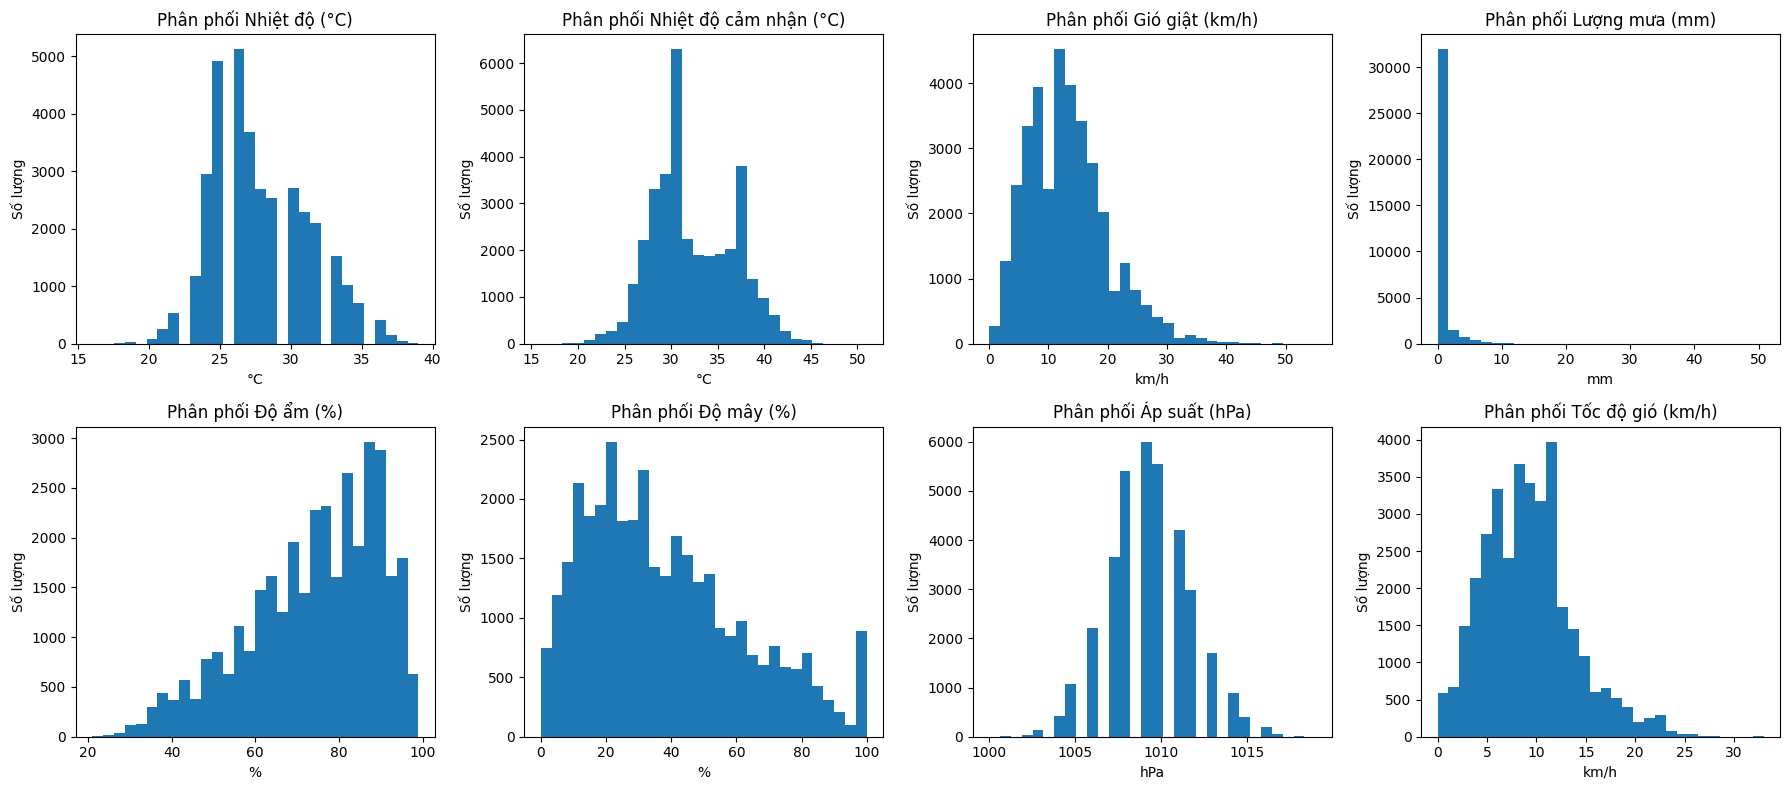

In [ ]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

plots = [
    ("Temp", "Phân phối Nhiệt độ (°C)", "°C"),
    ("Feels", "Phân phối Nhiệt độ cảm nhận (°C)", "°C"),
    ("Gust", "Phân phối Gió giật (km/h)", "km/h"),
    ("Rain", "Phân phối Lượng mưa (mm)", "mm"),
    ("Humidity", "Phân phối Độ ẩm (%)", "%"),
    ("Cloud", "Phân phối Độ mây (%)", "%"),
    ("Pressure", "Phân phối Áp suất (hPa)", "hPa"),
    ("Wind Speed", "Phân phối Tốc độ gió (km/h)", "km/h"),
]

for ax, (col, title, unit) in zip(axes, plots):
    data = weather[col].copy()
    # Humidity/Cloud trong file bạn đang là 0–1 -> đổi sang %
    if col in ["Humidity", "Cloud"]:
        data = data * 100
    ax.hist(data, bins=30)
    ax.set_title(title)
    ax.set_xlabel(unit)
    ax.set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

Nhiệt độ và nhiệt độ cảm nhận có phân phối khá tập trung, với phần lớn giá trị nằm trong một khoảng hẹp. Phân phối tương đối ổn định và không xuất hiện quá nhiều giá trị cực đoan, phản ánh đặc điểm khí hậu nhiệt đới ổn định của TP. Hồ Chí Minh.

Phân phối của lượng mưa (Rain) lệch mạnh về phía phải, với đa số thời điểm không có mưa hoặc lượng mưa rất nhỏ. Một số ít quan sát có lượng mưa lớn tạo thành các giá trị ngoại lai, phản ánh đặc điểm mưa lớn chỉ xảy ra trong những thời điểm nhất định.

Các biến độ ẩm, độ mây, áp suất và tốc độ gió có phân phối khác nhau, trong đó áp suất có xu hướng ổn định hơn, trong khi tốc độ gió và độ mây có độ phân tán lớn hơn, cho thấy sự biến động theo điều kiện thời tiết.

### 3.2.2 Phân tích giá trị ngoại lai (Outlier Analysis)




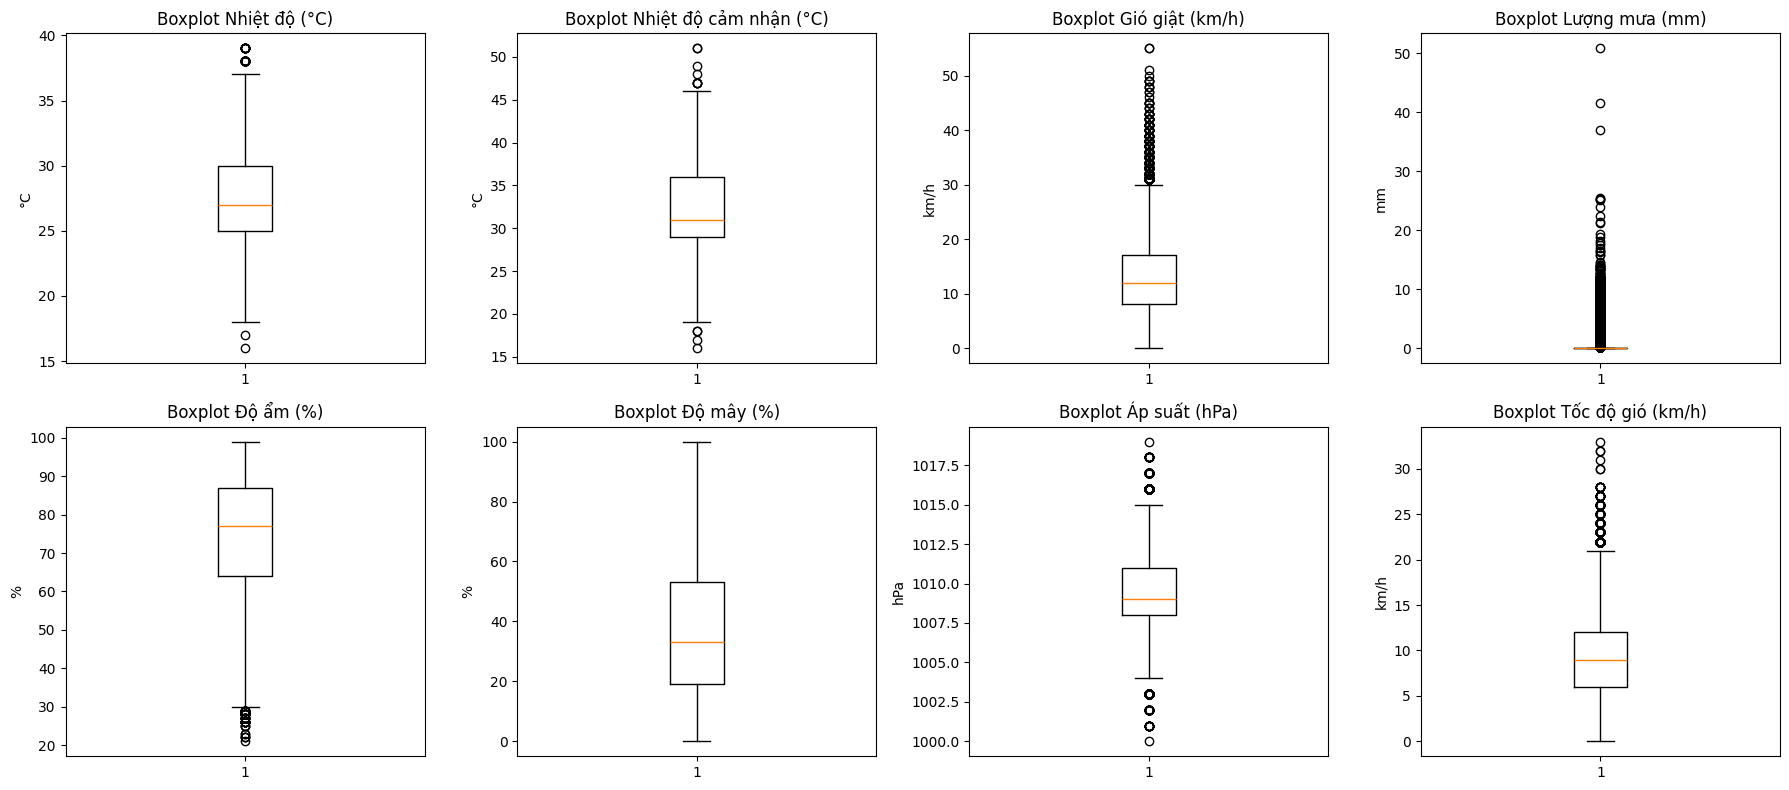

In [ ]:
fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.ravel()

for ax, (col, title, unit) in zip(axes, plots):
    data = weather[col].copy()
    if col in ["Humidity", "Cloud"]:
        data = data * 100
    ax.boxplot(data.dropna(), vert=True)
    ax.set_title(f"Boxplot {title.replace('Phân phối ', '')}")
    ax.set_ylabel(unit)

plt.tight_layout()
plt.show()

Boxplot cho thấy mức độ biến động khác nhau giữa các biến khí tượng. Trong khi áp suất không khí có biên độ dao động nhỏ và ổn định, lượng mưa và gió giật lại xuất hiện nhiều giá trị ngoại lai. Điều này cho thấy một số hiện tượng thời tiết chỉ xảy ra trong những điều kiện đặc biệt, trong khi các yếu tố nền như áp suất có xu hướng ổn định theo thời gian.

### 3.2.3 Phân tích mối quan hệ giữa các biến (Bivariate Analysis)

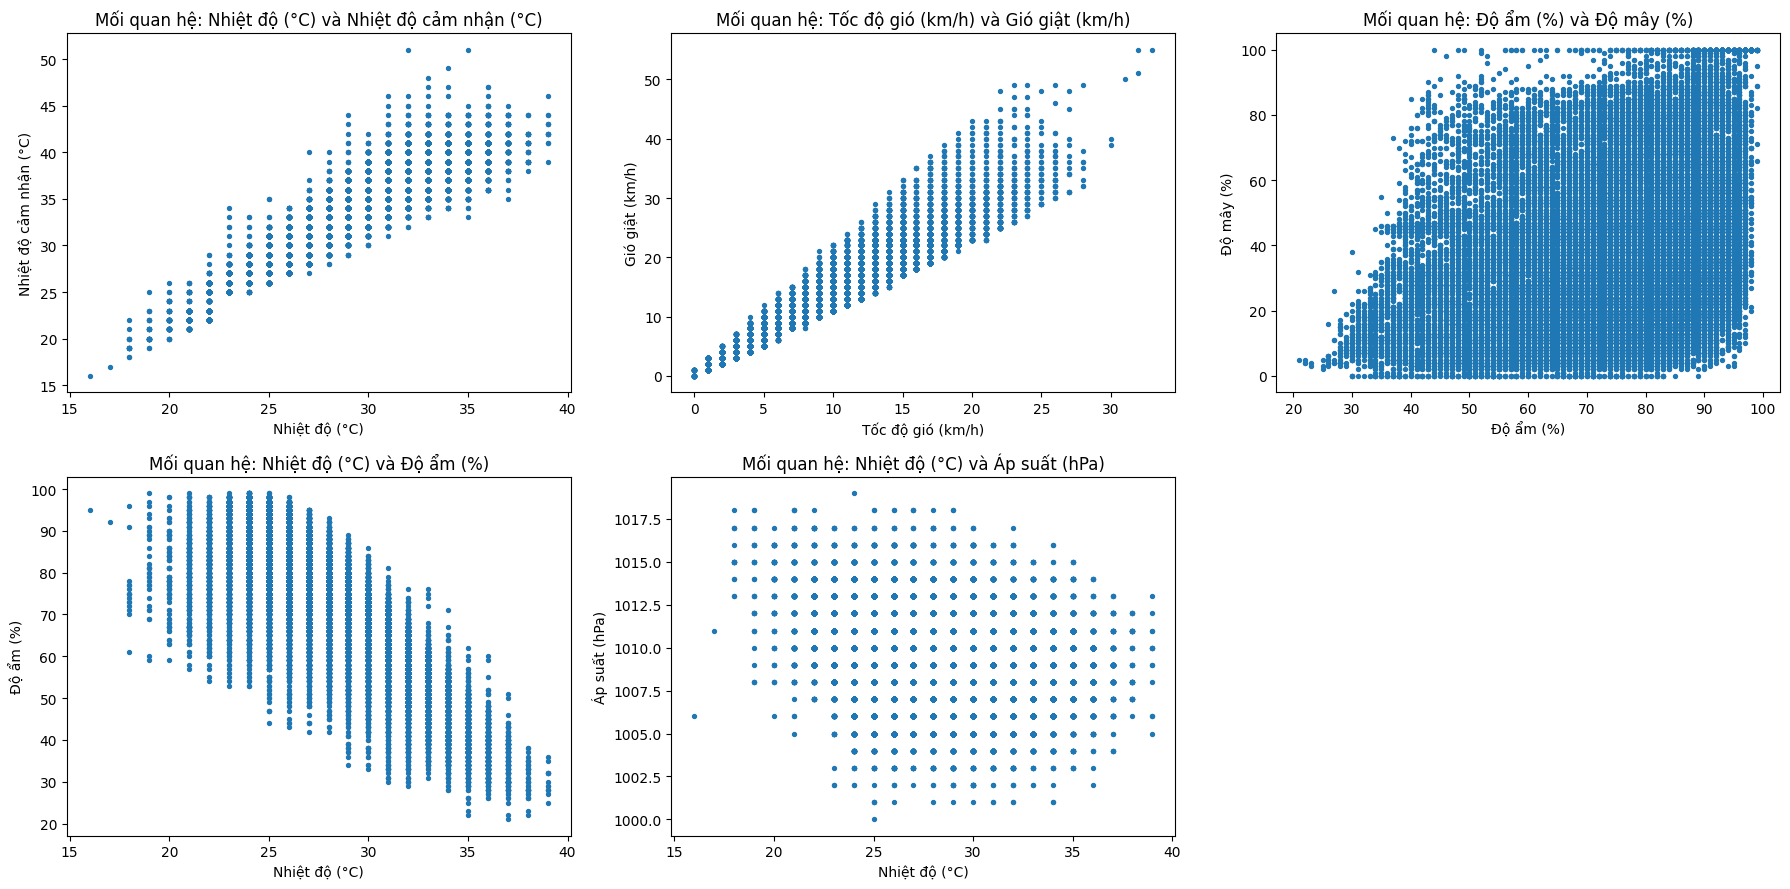

In [ ]:
pairs = [
    ("Temp", "Feels", "Nhiệt độ (°C)", "Nhiệt độ cảm nhận (°C)"),
    ("Wind Speed", "Gust", "Tốc độ gió (km/h)", "Gió giật (km/h)"),
    ("Humidity", "Cloud", "Độ ẩm (%)", "Độ mây (%)"),
    ("Temp", "Humidity", "Nhiệt độ (°C)", "Độ ẩm (%)"),
    ("Temp", "Pressure", "Nhiệt độ (°C)", "Áp suất (hPa)"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for i, ax in enumerate(axes):
    if i < len(pairs):
        x, y, xlabel, ylabel = pairs[i]
        xdata = weather[x]
        ydata = weather[y]
        if x in ["Humidity", "Cloud"]:
            xdata = xdata * 100
        if y in ["Humidity", "Cloud"]:
            ydata = ydata * 100

        ax.scatter(xdata, ydata, s=8)
        ax.set_title(f"Mối quan hệ: {xlabel} và {ylabel}")
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
    else:
        ax.axis("off")

plt.tight_layout()
plt.show()

Nhiệt độ và nhiệt độ cảm nhận có mối quan hệ tương quan dương rõ rệt. Khi nhiệt độ tăng, nhiệt độ cảm nhận cũng tăng theo, tuy nhiên trong một số trường hợp, nhiệt độ cảm nhận cao hơn nhiệt độ thực tế, có thể do ảnh hưởng của độ ẩm.

Tốc độ gió trung bình và gió giật có mối quan hệ dương, trong đó giá trị gió giật thường cao hơn tốc độ gió trung bình. Điều này phù hợp với đặc điểm vật lý của hiện tượng gió giật trong thời tiết thực tế.

Mối quan hệ giữa nhiệt độ và độ ẩm (hoặc độ mây) không thể hiện tính tuyến tính rõ ràng. Các điểm dữ liệu phân bố khá phân tán, cho thấy ảnh hưởng của nhiều yếu tố khí tượng khác nhau lên nhiệt độ.

### 3.2.4 Phân tích theo thời gian (Time Series Analysis)

/tmp/ipykernel_8043/524674436.py:19: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s2 = s.resample("M").mean()
/tmp/ipykernel_8043/524674436.py:21: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  s2 = s.resample("M").sum()


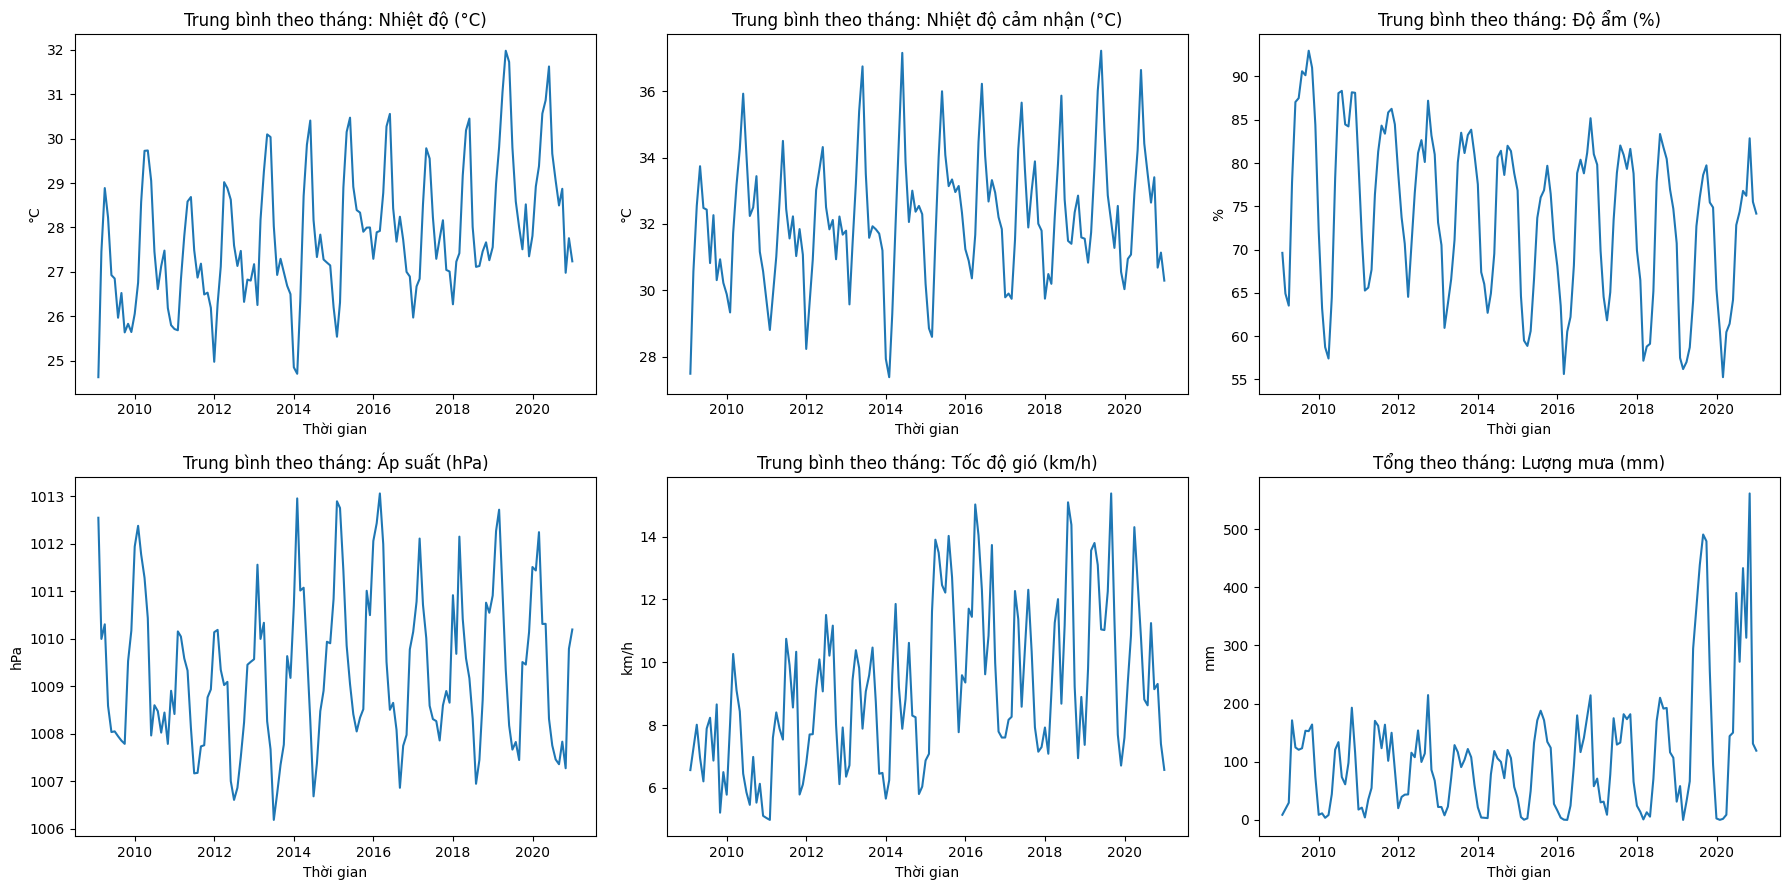

In [ ]:
series_specs = [
    ("Temp", "Trung bình theo tháng: Nhiệt độ (°C)", "°C", "mean"),
    ("Feels", "Trung bình theo tháng: Nhiệt độ cảm nhận (°C)", "°C", "mean"),
    ("Humidity", "Trung bình theo tháng: Độ ẩm (%)", "%", "mean"),
    ("Pressure", "Trung bình theo tháng: Áp suất (hPa)", "hPa", "mean"),
    ("Wind Speed", "Trung bình theo tháng: Tốc độ gió (km/h)", "km/h", "mean"),
    ("Rain", "Tổng theo tháng: Lượng mưa (mm)", "mm", "sum"),
]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = axes.ravel()

for ax, (col, title, unit, agg) in zip(axes, series_specs):
    s = weather[col].copy()
    if col in ["Humidity", "Cloud"]:
        s = s * 100

    if agg == "mean":
        s2 = s.resample("M").mean()
    else:
        s2 = s.resample("M").sum()

    ax.plot(s2.index, s2.values)
    ax.set_title(title)
    ax.set_ylabel(unit)
    ax.set_xlabel("Thời gian")

plt.tight_layout()
plt.show()

Nhiệt độ trung bình theo tháng thể hiện rõ tính mùa vụ, với các chu kỳ tăng giảm lặp lại theo từng năm. Điều này phản ánh đặc điểm khí hậu nhiệt đới gió mùa của khu vực TP. Hồ Chí Minh.

Lượng mưa theo tháng cho thấy sự tập trung rõ rệt vào một số thời điểm trong năm, tương ứng với mùa mưa. Trong khi đó, các tháng còn lại có lượng mưa rất thấp hoặc gần bằng không.

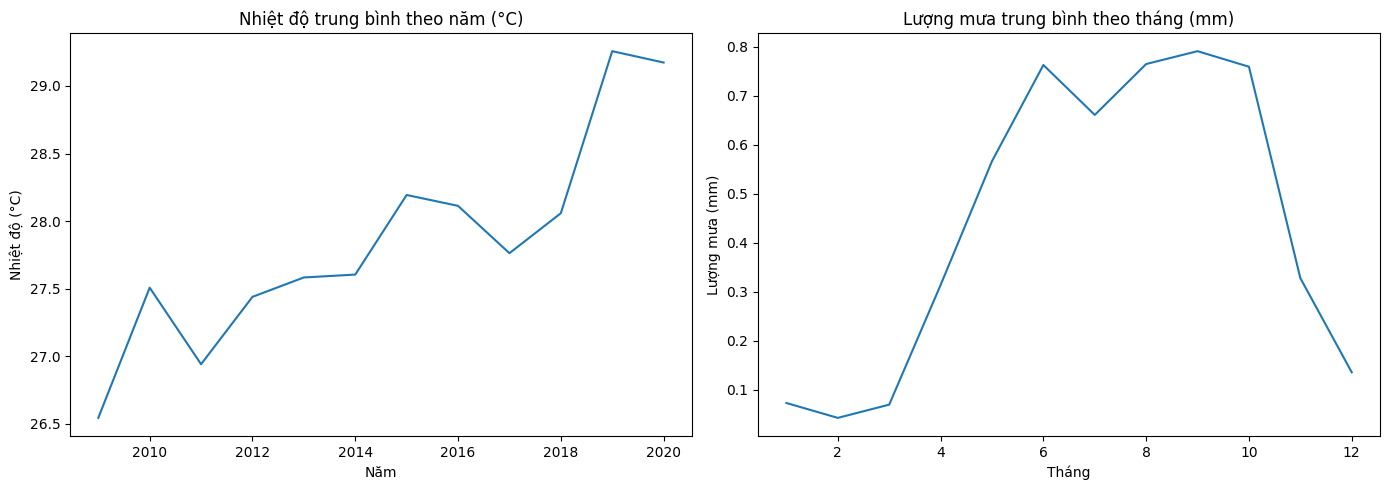

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Nhiệt độ trung bình theo năm
weather["year"] = weather.index.year
weather.groupby("year")["Temp"].mean().plot(ax=axes[0])

axes[0].set_title("Nhiệt độ trung bình theo năm (°C)")
axes[0].set_xlabel("Năm")
axes[0].set_ylabel("Nhiệt độ (°C)")

# Lượng mưa trung bình theo tháng
weather["month"] = weather.index.month
weather.groupby("month")["Rain"].mean().plot(ax=axes[1])

axes[1].set_title("Lượng mưa trung bình theo tháng (mm)")
axes[1].set_xlabel("Tháng")
axes[1].set_ylabel("Lượng mưa (mm)")

plt.tight_layout()
plt.show()

Nhiệt độ trung bình theo năm cho thấy xu hướng tăng nhẹ trong giai đoạn nghiên cứu, đặc biệt rõ hơn ở các năm gần cuối. Mặc dù mức tăng không đột ngột, xu hướng này cho thấy nền nhiệt tại TP. Hồ Chí Minh có dấu hiệu ấm lên theo thời gian.

Lượng mưa trung bình theo tháng thể hiện rõ tính mùa vụ, với lượng mưa thấp vào các tháng đầu năm và tăng mạnh từ khoảng giữa năm, đạt đỉnh vào các tháng mùa mưa trước khi giảm dần về cuối năm. Mô hình này phản ánh đặc trưng khí hậu nhiệt đới gió mùa của khu vực.

### 3.2.5 Phân tích biến phân loại (Categorical Analysis)

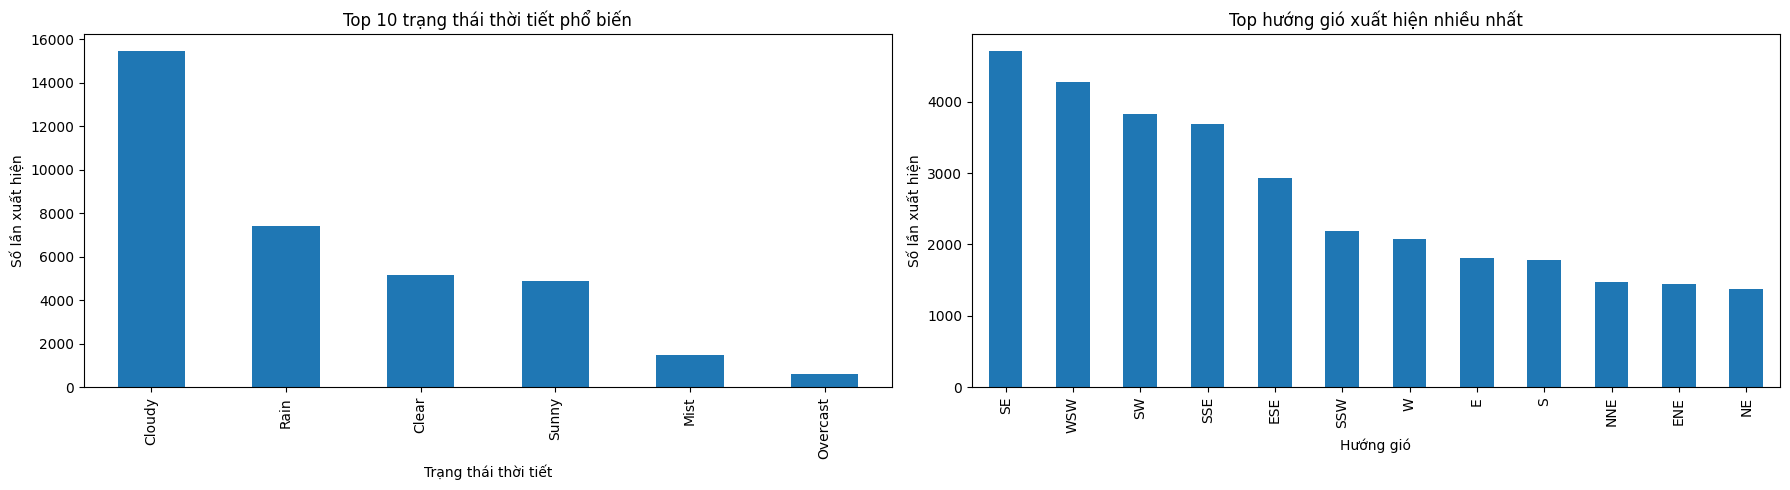

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

weather["Weather"].value_counts().head(10).plot(kind="bar", ax=axes[0])
axes[0].set_title("Top 10 trạng thái thời tiết phổ biến")
axes[0].set_xlabel("Trạng thái thời tiết")
axes[0].set_ylabel("Số lần xuất hiện")

weather["Wind Direction"].value_counts().head(12).plot(kind="bar", ax=axes[1])
axes[1].set_title("Top hướng gió xuất hiện nhiều nhất")
axes[1].set_xlabel("Hướng gió")
axes[1].set_ylabel("Số lần xuất hiện")

plt.tight_layout()
plt.show()

Các trạng thái thời tiết phổ biến nhất bao gồm các điều kiện như nhiều mây, mưa và sương mù. Điều này phản ánh đặc điểm thời tiết thường gặp tại TP. Hồ Chí Minh trong giai đoạn nghiên cứu.

Một số hướng gió xuất hiện với tần suất cao hơn so với các hướng khác, cho thấy sự tồn tại của hướng gió chủ đạo trong khu vực nghiên cứu.

## 3.3 Phân tích bổ sung

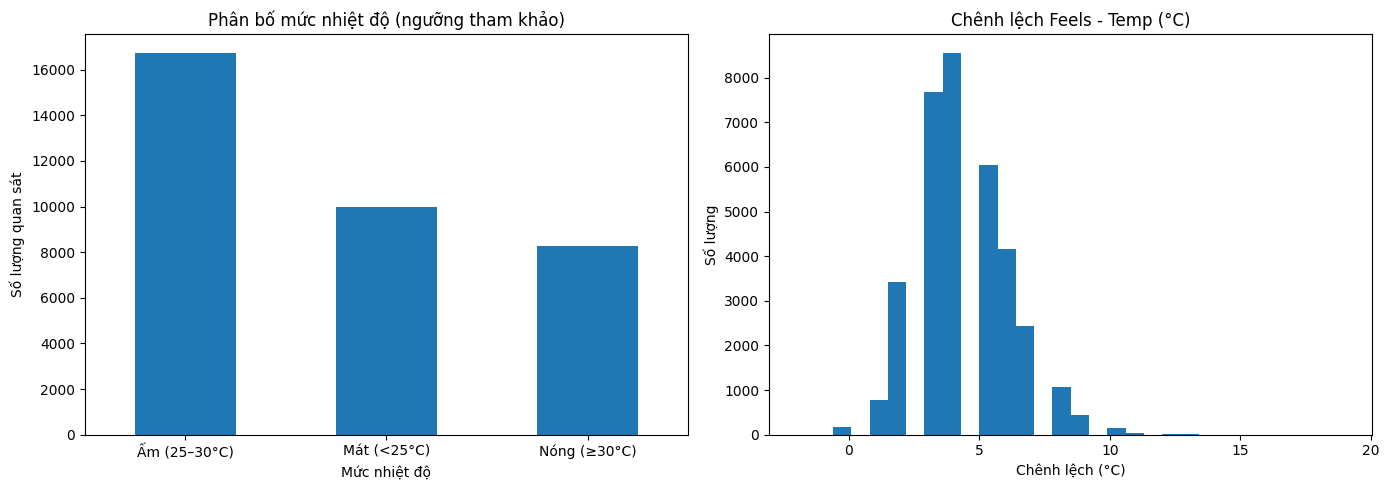

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart mức nhiệt độ
weather["Mức_nhiệt_độ"] = pd.cut(
    weather["Temp"],
    bins=[0, 25, 30, 100],
    labels=["Mát (<25°C)", "Ấm (25–30°C)", "Nóng (≥30°C)"]
)
weather["Mức_nhiệt_độ"].value_counts().plot(kind="bar", ax=axes[0])
axes[0].set_title("Phân bố mức nhiệt độ (ngưỡng tham khảo)")
axes[0].set_xlabel("Mức nhiệt độ")
axes[0].set_ylabel("Số lượng quan sát")
axes[0].tick_params(axis="x", rotation=0)

# Histogram chênh lệch cảm nhận
weather["Chênh_lệch_cảm_nhận"] = weather["Feels"] - weather["Temp"]
axes[1].hist(weather["Chênh_lệch_cảm_nhận"], bins=30)
axes[1].set_title("Chênh lệch Feels - Temp (°C)")
axes[1].set_xlabel("Chênh lệch (°C)")
axes[1].set_ylabel("Số lượng")

plt.tight_layout()
plt.show()

Phân bố mức nhiệt độ cho thấy phần lớn thời gian nhiệt độ tại TP. Hồ Chí Minh nằm trong nhóm “Ấm (25–30°C)” và “Nóng (≥30°C)”, trong khi số ngày có nhiệt độ dưới 25°C chiếm tỷ lệ thấp. Điều này cho thấy nền nhiệt cao và ổn định là đặc điểm nổi bật của khu vực nghiên cứu.

Biểu đồ chênh lệch giữa nhiệt độ cảm nhận và nhiệt độ thực tế (Feels − Temp) cho thấy phần lớn giá trị là dương, tức là nhiệt độ cảm nhận thường cao hơn nhiệt độ đo được. Điều này phản ánh ảnh hưởng đáng kể của các yếu tố như độ ẩm và điều kiện môi trường, góp phần lý giải cảm giác oi bức thường gặp tại TP. Hồ Chí Minh.

/tmp/ipykernel_8043/1341023742.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  weather[["Temp", "Feels"]].resample("M").mean().plot(figsize=(12,4))


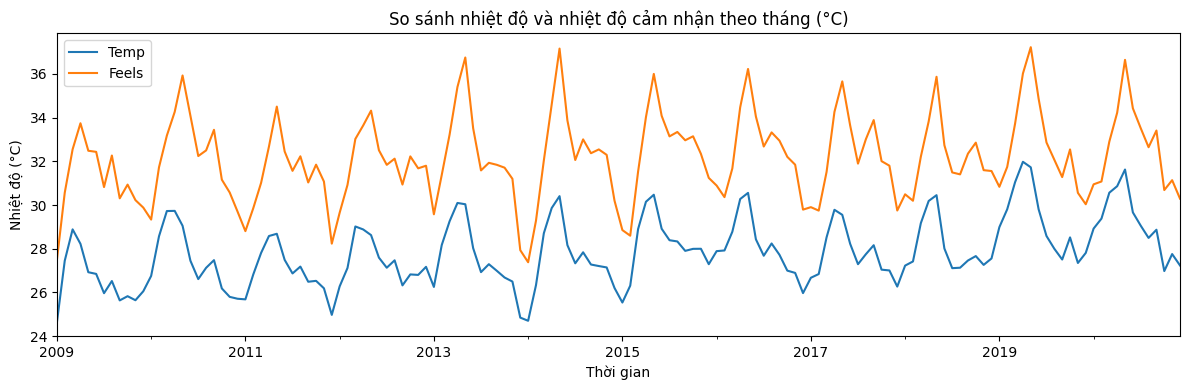

In [ ]:
weather[["Temp", "Feels"]].resample("M").mean().plot(figsize=(12,4))
plt.title("So sánh nhiệt độ và nhiệt độ cảm nhận theo tháng (°C)")
plt.xlabel("Thời gian")
plt.ylabel("Nhiệt độ (°C)")
plt.tight_layout()
plt.show()

In [ ]:
weather['Rain'].value_counts()

,count
Rain,
0.0,26807
0.1,1152
0.2,612
0.3,538
0.4,420
...,...
37.0,1
21.2,1
12.6,1


Biểu đồ so sánh nhiệt độ và nhiệt độ cảm nhận theo thời gian cho thấy hai đại lượng này có xu hướng biến động đồng pha và cùng thể hiện tính mùa vụ rõ rệt. Tuy nhiên, nhiệt độ cảm nhận luôn cao hơn nhiệt độ thực tế trong hầu hết các thời điểm, đặc biệt vào các giai đoạn nhiệt độ cao.

Khoảng cách tương đối ổn định giữa hai đường biểu diễn cho thấy cảm giác nóng tại TP. Hồ Chí Minh không chỉ phụ thuộc vào nhiệt độ mà còn chịu ảnh hưởng thường xuyên của các yếu tố khí tượng khác như độ ẩm và gió.

## 3.4 Kết luận
Các phân tích trên cho thấy dữ liệu thời tiết TP. Hồ Chí Minh mang đặc trưng rõ rệt của khí hậu nhiệt đới gió mùa. Sự ổn định của nhiệt độ, tính mùa vụ của lượng mưa và mối quan hệ hợp lý giữa các biến khí tượng cho thấy dữ liệu có độ tin cậy cao và phản ánh tốt điều kiện thời tiết thực tế.

# 4 Phân tích Khám phá Dữ liệu (EDA)

## 4.1 Chuẩn bị dữ liệu cho ML


In [ ]:
# Kiểm tra nếu Datetime đang là Index thì mới reset
if not isinstance(weather.index, pd.RangeIndex):
    weather = weather.reset_index()

# Đảm bảo cột Datetime đã ở dạng chuẩn để trích xuất
weather['Datetime'] = pd.to_datetime(weather['Datetime'])

# Trích xuất trực tiếp từ cột Datetime (thay vì dùng weather.index)
weather['Month'] = weather['Datetime'].dt.month
weather['Hour'] = weather['Datetime'].dt.hour

# Xóa bỏ các cột rác phát sinh do reset_index nhiều lần (nếu có)
cols_to_drop = ['level_0', 'index']
weather = weather.drop(columns=[c for c in cols_to_drop if c in weather.columns])

print("Các cột mới đã thêm thành công:")
print(weather[['Datetime', 'Month', 'Hour']].head())

Các cột mới đã thêm thành công:
             Datetime  Month  Hour
0 2009-01-01 00:00:00      1     0
1 2009-01-01 03:00:00      1     3
2 2009-01-01 06:00:00      1     6
3 2009-01-01 09:00:00      1     9
4 2009-01-01 12:00:00      1    12


In [ ]:
# TẠO CÁC BIẾN KẾT HỢP (FEATURE INTERACTION)

# 1. Chỉ số nhiệt (Heat Index) - Kết hợp Nhiệt độ và Độ ẩm
# Phản ánh mức độ oi bức, một chỉ số quan trọng để dự báo mưa giông
weather['Heat_Index'] = weather['Temp'] * (weather['Humidity'] / 100)

# 2. Chỉ số Gió lạnh (Wind Chill) - Kết hợp Nhiệt độ và Tốc độ gió
# Phản ánh cảm giác lạnh thực tế khi có gió
weather['Wind_Chill'] = weather['Temp'] - (0.1 * weather['Wind Speed'])

print("Đã tạo xong các biến kết hợp. Số lượng cột hiện tại:", weather.shape[1])

Đã tạo xong các biến kết hợp. Số lượng cột hiện tại: 20


In [ ]:
import numpy as np

constant_cols = [col for col in weather.columns if weather[col].nunique() <= 1]

numeric_df = weather.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.9)]

useless_obj_cols = ['Datetime'] if 'Datetime' in weather.columns else []

drop_list = list(set(constant_cols + high_corr_cols + useless_obj_cols))

print("KẾT QUẢ TỰ ĐỘNG PHÂN TÍCH CỘT")
print(f"Cột không biến đổi: {constant_cols}")
print(f"Cột có tương quan cao (>0.9): {high_corr_cols}")
print(f"Cột định dạng không phù hợp: {useless_obj_cols}")
print(f"\n=> TỔNG CỘNG DANH SÁCH LOẠI BỎ: {drop_list}")

KẾT QUẢ TỰ ĐỘNG PHÂN TÍCH CỘT
Cột không biến đổi: []
Cột có tương quan cao (>0.9): ['Feels', 'Wind Speed', 'Month', 'Wind_Chill']
Cột định dạng không phù hợp: ['Datetime']

=> TỔNG CỘNG DANH SÁCH LOẠI BỎ: ['Wind_Chill', 'Datetime', 'Wind Speed', 'Month', 'Feels']


In [ ]:
# Danh sách máy đề nghị tự động
auto_drop = list(set(constant_cols + high_corr_cols + useless_obj_cols))

# Những cột quan trọng dù tương quan cao vẫn nên giữ để tăng độ chính xác
keep_for_accuracy = ['Month', 'Wind_Chill', 'Heat_Index']

# Danh sách cuối cùng thực sự cần xóa
final_drop_list = [col for col in auto_drop if col not in keep_for_accuracy]

print(f"=> DANH SÁCH THỰC TẾ SẼ LOẠI BỎ: {final_drop_list}")

=> DANH SÁCH THỰC TẾ SẼ LOẠI BỎ: ['Datetime', 'Wind Speed', 'Feels']


In [ ]:
outlier_indices = []

cols_to_check = ['Temp', 'Humidity', 'Wind Speed', 'Pressure']

for col in cols_to_check:
    Q1 = weather[col].quantile(0.25)
    Q3 = weather[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = weather[(weather[col] < lower_bound) | (weather[col] > upper_bound)]
    outlier_indices.extend(outliers.index.tolist())

outlier_indices = list(set(outlier_indices))
df_outliers = weather.loc[outlier_indices]

print(f"Tổng số dòng bị loại bỏ: {len(df_outliers)}")
print("5 dòng tiêu biểu bị loại:")
df_outliers.head()

Tổng số dòng bị loại bỏ: 1027
5 dòng tiêu biểu bị loại:


,Datetime,Weather,Temp,Feels,Gust,Rain,Humidity,Cloud,Pressure,Vis,Wind Speed,Wind Direction,year,month,Mức_nhiệt_độ,Chênh_lệch_cảm_nhận,Month,Hour,Heat_Index,Wind_Chill
10244,2012-07-04 12:00:00,Cloudy,30.0,37.0,17.0,0.0,0.71,0.36,1003.0,Excellent,14.0,WSW,2012,7,Ấm (25–30°C),7.0,7,12,0.2130,28.6
32773,2020-03-20 15:00:00,Cloudy,35.0,36.0,29.0,0.0,0.32,0.07,1008.0,Excellent,25.0,SE,2020,3,Nóng (≥30°C),1.0,3,15,0.1120,32.5
32774,2020-03-20 18:00:00,Cloudy,32.0,35.0,32.0,0.0,0.56,0.03,1009.0,Excellent,23.0,SE,2020,3,Nóng (≥30°C),3.0,3,18,0.1792,29.7
10245,2012-07-04 15:00:00,Sunny,30.0,37.0,21.0,0.0,0.72,0.24,1001.0,Excellent,15.0,WSW,2012,7,Ấm (25–30°C),7.0,7,15,0.2160,28.5
10246,2012-07-04 18:00:00,Cloudy,27.0,31.0,19.0,0.0,0.87,0.32,1003.0,Excellent,10.0,SW,2012,7,Ấm (25–30°C),4.0,7,18,0.2349,26.0


In [ ]:
print(" DÒNG ĐẦU TIÊN CỦA DỮ LIỆU HUẤN LUYỆN (X)")
display(X.head())

 DÒNG ĐẦU TIÊN CỦA DỮ LIỆU HUẤN LUYỆN (X)


,Temp,Gust,Rain,Humidity,Cloud,Pressure,Month,Hour,Heat_Index,Wind_Chill,...,Wind Direction_NNW,Wind Direction_NW,Wind Direction_S,Wind Direction_SE,Wind Direction_SSE,Wind Direction_SSW,Wind Direction_SW,Wind Direction_W,Wind Direction_WNW,Wind Direction_WSW
0,23.0,15.0,0.0,0.97,1.00,1010.0,1,0,0.2231,22.1,...,True,False,False,False,False,False,False,False,False,False
1,22.0,13.0,0.4,0.97,0.84,1010.0,1,3,0.2134,21.1,...,True,False,False,False,False,False,False,False,False,False
2,22.0,8.0,0.0,0.98,1.00,1011.0,1,6,0.2156,21.4,...,False,False,False,False,False,False,False,False,False,False
3,27.0,7.0,0.1,0.83,0.64,1011.0,1,9,0.2241,26.4,...,False,False,False,False,False,False,False,False,False,False
4,28.0,3.0,0.0,0.76,0.62,1010.0,1,12,0.2128,27.7,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
# Kiểm tra Outlier cho các biến quan trọng
cols_to_check = ['Temp', 'Humidity', 'Wind Speed', 'Pressure']
outlier_list = []

for col in cols_to_check:
    Q1 = weather[col].quantile(0.25)
    Q3 = weather[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Lấy các dòng vi phạm
    outliers = weather[(weather[col] < lower_bound) | (weather[col] > upper_bound)]
    outlier_list.append(outliers)

# Gộp lại thành một bảng danh sách Outlier duy nhất
df_outliers = pd.concat(outlier_list).drop_duplicates()
print(f"Số lượng dòng nghi ngờ là Outlier: {len(df_outliers)}")
display(df_outliers.head())

Số lượng dòng nghi ngờ là Outlier: 1027


,Datetime,Weather,Temp,Feels,Gust,Rain,Humidity,Cloud,Pressure,Vis,Wind Speed,Wind Direction,year,month,Mức_nhiệt_độ,Chênh_lệch_cảm_nhận,Month,Hour,Heat_Index,Wind_Chill
3436,2010-03-06 12:00:00,Sunny,39.0,43.0,5.0,0.0,0.29,0.19,1011.0,Excellent,4.0,S,2010,3,Nóng (≥30°C),4.0,3,12,0.1131,38.6
3484,2010-03-12 12:00:00,Sunny,39.0,42.0,5.0,0.0,0.28,0.16,1013.0,Excellent,5.0,ESE,2010,3,Nóng (≥30°C),3.0,3,12,0.1092,38.5
3508,2010-03-15 12:00:00,Sunny,39.0,42.0,9.0,0.0,0.27,0.11,1010.0,Excellent,8.0,ESE,2010,3,Nóng (≥30°C),3.0,3,12,0.1053,38.2
3516,2010-03-16 12:00:00,Sunny,38.0,39.0,18.0,0.0,0.23,0.03,1011.0,Excellent,16.0,ESE,2010,3,Nóng (≥30°C),1.0,3,12,0.0874,36.4
3540,2010-03-19 12:00:00,Sunny,38.0,40.0,7.0,0.0,0.26,0.16,1011.0,Excellent,6.0,SE,2010,3,Nóng (≥30°C),2.0,3,12,0.0988,37.4


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score
from sklearn.metrics import confusion_matrix, precision_score, recall_score
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.metrics import confusion_matrix

In [ ]:
# 1. Loại bỏ các biến gây nhiễu và đa cộng tuyến
# Loại bỏ Datetime (không định dạng số), các biến có tương quan quá cao (Feels, Wind Speed),
# và biến phân loại 'Mức_nhiệt_độ' không dùng cho scaling
drop_cols = ['Datetime', 'Wind Speed', 'Feels', 'Mức_nhiệt_độ', 'index', 'level_0', 'year', 'Chênh_lệch_cảm_nhận']
X = weather.drop(columns=[col for col in drop_cols if col in weather.columns] + ['Weather'])
y = weather['Weather']

# 2. Mã hóa nhãn mục tiêu (Target Encoding)
le = LabelEncoder()
y = le.fit_transform(y)

# 3. Mã hóa các biến phân loại (Feature Encoding)
X = pd.get_dummies(X, columns=['Vis', 'Wind Direction'], drop_first=True)

# 4. Chia tập dữ liệu huấn luyện và kiểm tra (Tỷ lệ 80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 5. Chuẩn hóa thang đo dữ liệu (Feature Scaling)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Kiểm tra kích thước dữ liệu sau xử lý
print("KẾT QUẢ CHUẨN BỊ DỮ LIỆU")
print(f"Số lượng mẫu huấn luyện (Train): {X_train_scaled.shape[0]}")
print(f"Số lượng mẫu kiểm tra (Test): {X_test_scaled.shape[0]}")
print(f"Số lượng đặc trưng sau Encoding: {X_train_scaled.shape[1]}")

KẾT QUẢ CHUẨN BỊ DỮ LIỆU
Số lượng mẫu huấn luyện (Train): 27980
Số lượng mẫu kiểm tra (Test): 6996
Số lượng đặc trưng sau Encoding: 29


In [ ]:
# Mô hình 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

y_pred_log = log_reg.predict(X_test_scaled)

print("Mô hình 1: Logistic Regression")
print(f"Accuracy: {accuracy_score(y_test, y_pred_log):.4f}")
print(classification_report(y_test, y_pred_log, target_names=le.classes_))

Mô hình 1: Logistic Regression
Accuracy: 0.8289
              precision    recall  f1-score   support

       Clear       0.82      0.82      0.82      1047
      Cloudy       0.79      0.88      0.84      3069
        Mist       0.97      1.00      0.98       287
    Overcast       0.95      0.87      0.91       129
        Rain       0.94      0.76      0.84      1523
       Sunny       0.75      0.72      0.73       941

    accuracy                           0.83      6996
   macro avg       0.87      0.84      0.85      6996
weighted avg       0.84      0.83      0.83      6996



In [ ]:
# Mô hình 2: Random Forest
rf_clf = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=42,
                                class_weight='balanced', n_jobs=-1)

rf_clf.fit(X_train_scaled, y_train)

y_pred_rf = rf_clf.predict(X_test_scaled)

print("Mô hình 2: Random Forest")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

Mô hình 2: Random Forest
Accuracy: 0.9220
              precision    recall  f1-score   support

       Clear       0.94      0.97      0.95      1047
      Cloudy       0.92      0.90      0.91      3069
        Mist       1.00      1.00      1.00       287
    Overcast       0.97      0.97      0.97       129
        Rain       0.95      0.89      0.92      1523
       Sunny       0.84      0.96      0.90       941

    accuracy                           0.92      6996
   macro avg       0.94      0.95      0.94      6996
weighted avg       0.92      0.92      0.92      6996



In [ ]:
# Mô hình 3: SVM
svm_clf = SVC(kernel='rbf', random_state=42)
svm_clf.fit(X_train_scaled, y_train)

# 2. Dự đoán
y_pred_svm = svm_clf.predict(X_test_scaled)

# 3. In kết quả
print("Mô hình 3: SUPPORT VECTOR MACHINE")
print(f"Accuracy: {accuracy_score(y_test, y_pred_svm):.4f}")
print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

Mô hình 3: SUPPORT VECTOR MACHINE
Accuracy: 0.8402
              precision    recall  f1-score   support

       Clear       0.84      0.86      0.85      1047
      Cloudy       0.81      0.89      0.85      3069
        Mist       0.94      1.00      0.97       287
    Overcast       0.92      0.76      0.83       129
        Rain       0.94      0.72      0.82      1523
       Sunny       0.79      0.79      0.79       941

    accuracy                           0.84      6996
   macro avg       0.88      0.84      0.85      6996
weighted avg       0.85      0.84      0.84      6996



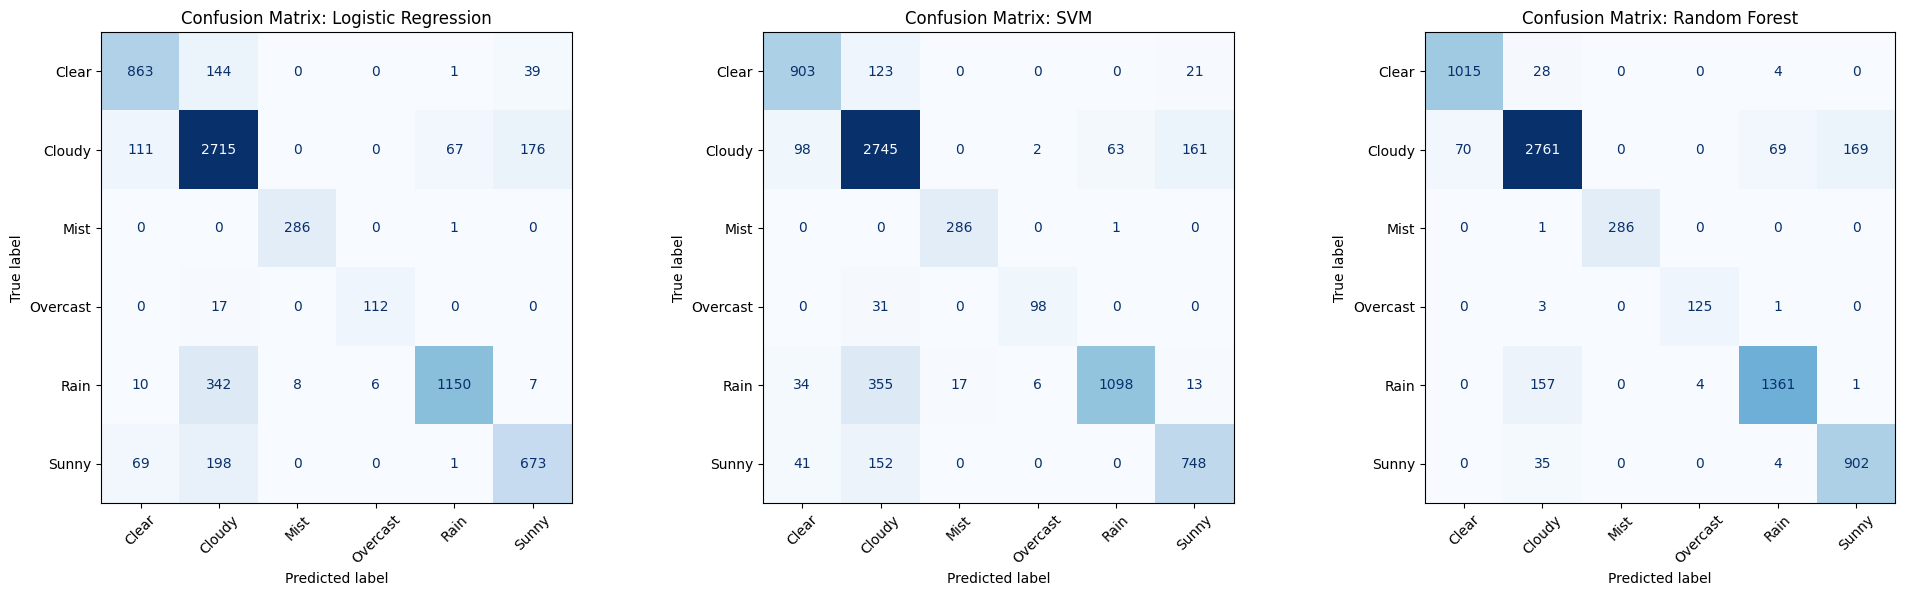

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

models_to_plot = {
    'Logistic Regression': log_reg,
    'SVM': svm_clf,
    'Random Forest': rf_clf
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for i, (name, model) in enumerate(models_to_plot.items()):
    y_pred_model = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred_model)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
    disp.plot(ax=axes[i], cmap='Blues', colorbar=False)
    axes[i].set_title(f'Confusion Matrix: {name}')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

/tmp/ipykernel_8043/2880169244.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')


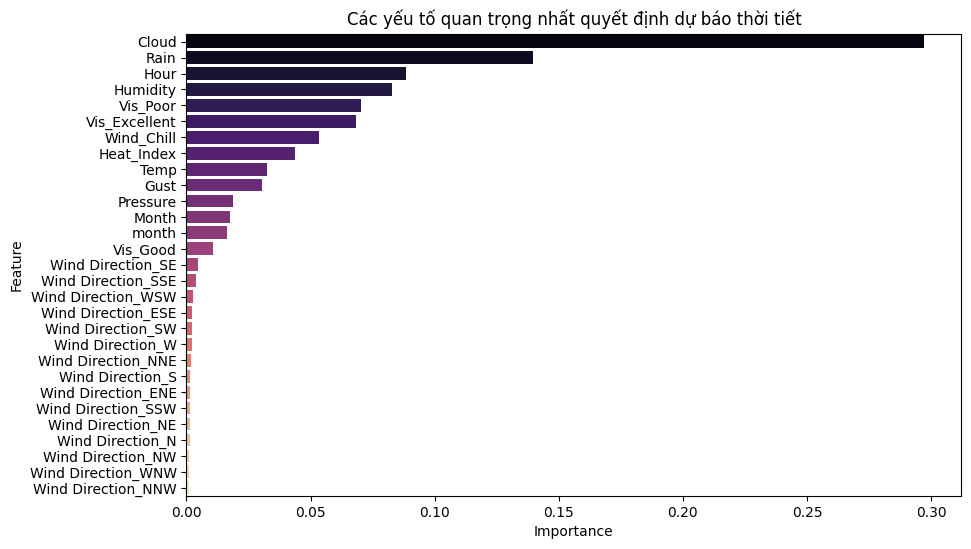

In [ ]:
# Xem tầm quan trọng của các cột
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

importances = rf_clf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='magma')
plt.title('Các yếu tố quan trọng nhất quyết định dự báo thời tiết')
plt.show()

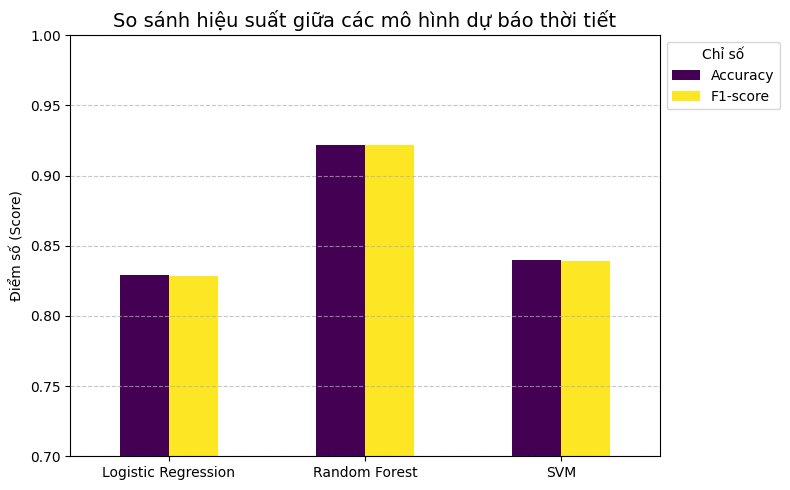

In [ ]:
## Nhận xét kết quả huấn luyện và đánh giá mô hình

### 1. So sánh hiệu suất các mô hình:

*   **Random Forest** cho thấy hiệu suất vượt trội nhất với Accuracy và F1-score cao nhất (khoảng 0.92).
*   **Support Vector Machine (SVM)** đứng thứ hai với Accuracy khoảng 0.84.
*   **Logistic Regression** có hiệu suất thấp nhất trong ba mô hình, với Accuracy khoảng 0.83.

Điều này cho thấy Random Forest là lựa chọn tốt nhất cho bài toán phân loại trạng thái thời tiết này, có khả năng xử lý tốt các mối quan hệ phức tạp trong dữ liệu.

### 2. Kết quả tối ưu hóa mô hình Random Forest (Grid Search):

*   Sau khi tinh chỉnh siêu tham số bằng Grid Search, các tham số tốt nhất được tìm thấy là:
    *   `class_weight`: 'balanced'
    *   `criterion`: 'gini'
    *   `max_depth`: 30
    *   `min_samples_split`: 2
    *   `n_estimators`: 300
*   Accuracy của mô hình Random Forest sau khi cải thiện là **0.9215**, tương đương với hiệu suất ban đầu, cho thấy các tham số mặc định của RandomForestClassifier đã khá tốt hoặc việc tinh chỉnh chỉ mang lại cải thiện nhỏ.

### 3. Đánh giá bằng Cross-validation:

*   Mô hình Random Forest tốt nhất đã được đánh giá bằng cross-validation 5 folds trên tập huấn luyện.
*   **Độ chính xác trung bình (Mean Accuracy)**: 0.9263
*   **Độ lệch chuẩn (Standard Deviation)**: 0.0031

Kết quả này cho thấy mô hình không chỉ có hiệu suất cao mà còn ổn định, với độ lệch chuẩn thấp, ngụ ý rằng mô hình hoạt động nhất quán trên các tập dữ liệu con khác nhau và không bị quá khớp (overfitting) với tập huấn luyện cụ thể.

### 4. Tầm quan trọng của các đặc trưng (Feature Importance):

Biểu đồ tầm quan trọng của các đặc trưng cho thấy:

*   Các biến như **Temp (Nhiệt độ)**, **Heat_Index (Chỉ số nhiệt)**, **Humidity (Độ ẩm)**, **Rain (Lượng mưa)** và **Pressure (Áp suất)** là những yếu tố quan trọng nhất trong việc dự đoán trạng thái thời tiết.
*   Các biến liên quan đến gió (Gust, Wind Direction) cũng đóng góp nhưng ít quan trọng hơn so với các yếu tố nhiệt độ, độ ẩm và lượng mưa.

### Kết luận tổng thể:

Quá trình EDA đã giúp làm sạch và hiểu rõ dữ liệu, dẫn đến việc xây dựng mô hình Random Forest hiệu quả và ổn định. Mô hình này có khả năng dự đoán trạng thái thời tiết với độ chính xác cao, dựa trên các yếu tố khí tượng chính. Sự ổn định của mô hình được xác nhận qua cross-validation và phân tích tầm quan trọng của các đặc trưng cung cấp cái nhìn sâu sắc về những yếu tố ảnh hưởng nhất đến thời tiết tại TP. Hồ Chí Minh.

In [ ]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy'],
    'class_weight': ['balanced']
}

grid_search = GridSearchCV(estimator=RandomForestClassifier(random_state=42),
                           param_grid=param_grid, scoring='accuracy',
                           cv=5, n_jobs=-1, verbose=2)

grid_search.fit(X_train_scaled, y_train)

print("Bộ thông số tốt nhất tìm được:", grid_search.best_params_)

best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

print("\n MÔ HÌNH RANDOM FOREST SAU KHI CẢI THIỆN")
print(f"Accuracy mới: {accuracy_score(y_test, y_pred_best):.4f}")

Fitting 5 folds for each of 54 candidates, totalling 270 fits
Bộ thông số tốt nhất tìm được: {'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 30, 'min_samples_split': 2, 'n_estimators': 300}

 MÔ HÌNH RANDOM FOREST SAU KHI CẢI THIỆN
Accuracy mới: 0.9215


In [ ]:
final_model = grid_search.best_estimator_

cv_results = cross_val_score(final_model, X_train_scaled, y_train, cv=5)

print(f"Kết quả từng lần chạy: {cv_results}")
print(f"Độ chính xác trung bình: {cv_results.mean():.4f}")
print(f"Độ lệch chuẩn (Sự biến động): {cv_results.std():.4f}")

Kết quả từng lần chạy: [0.9238742  0.9224446  0.92566119 0.92834167 0.93120086]
Độ chính xác trung bình: 0.9263
Độ lệch chuẩn (Sự biến động): 0.0031
